# 串扰仿真 v01 —— 短焦 16 激光器编码串扰检测

> 理想回波模型（δ 函数、100% 探测率），不考虑蒙卡与波形展宽。
> 每个激光器独立编码，通过在时序图（kick 级别）中指定发光顺序。
> 目标的回波被所有激光器同时接收，落入某个激光器的 TOF 窗即被该激光器记录。

## 核心概念
- **Sync（角度）**：一个测量周期，包含多个 kick。
- **Kick（触发节拍）**：一个 kick 内，若干激光器同时（或接近同时）发光，编码延迟拉开微小时间差。
- **编码**：每个激光器有 `tx_trig_dly`（1ns 步长）和 `FPGA 抖动`（8ns 步长），
  决定其相对 kick 基线的偏移。
- **TOF 窗**：激光器发光后开启，有效范围 = 0～D_max×N（如 0～600m，N=2）。
- **串扰鬼影**：激光器 A 发射的脉冲被目标反射后，落入激光器 B 的 TOF 窗内，
  B 按自己的"发光时刻﹣回波时刻"计算距离，产生鬼影。

## 缩写
- TOF（Time of Flight，飞行时间）
- SPAD（Single-Photon Avalanche Diode，单光子雪崩二极管）
- FPGA（Field-Programmable Gate Array，现场可编程门阵列）


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

for _f in ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "Source Han Sans SC"]:
    try:
        matplotlib.rcParams["font.sans-serif"] = [_f]; break
    except Exception:
        continue
matplotlib.rcParams["axes.unicode_minus"] = False

C_LIGHT = 2.99792458e8      # 光速 [m/s]
NS = 1e-9                    # 1 ns [s]

print("模块导入完成。")
print(f"光速 = {C_LIGHT:.3e} m/s")
print(f"1 ns 光程 = {C_LIGHT*1e-9:.3f} m（往返折半 = {C_LIGHT*1e-9/2:.3f} m）")


模块导入完成。
光速 = 2.998e+08 m/s
1 ns 光程 = 0.300 m（往返折半 = 0.150 m）


In [2]:
# ============================================================================
# 系统参数（可调）
# ============================================================================

N_LASERS = 16                # 激光器数（短焦模组）
D_MAX = 300.0                # 雷达有效射程 [m]（0～300m，可调）
D_RANGE_N = 2                # 探测距离倍数（N 倍射程内的回波都可能被记录，用于模拟 TOF 外鬼影）
D_DETECT_MAX = D_MAX * D_RANGE_N  # 最大可探测距离 [m]（默认 600m）

# 目标扫描参数
D_TARGET_MIN = 0.0           # 扫描目标最近距离 [m]
D_TARGET_MAX = D_DETECT_MAX  # 扫描目标最远距离 [m]
D_TARGET_STEP = 0.5          # 目标间距 [m]（可调；0.5m 约 3.3ns 往返时差）
D_targets = np.arange(D_TARGET_MIN, D_TARGET_MAX + D_TARGET_STEP/2, D_TARGET_STEP)

# Kick 间间隔
KICK_SPACING = 1000e-9       # 相邻 kick 基线时间间隔 [s]（默认 1 us，可调）
SYNC_DURATION = KICK_SPACING * 10  # 每个 sync 总时长 [s]（自动推导，可覆盖）

print(f"系统参数:")
print(f"  激光器数: {N_LASERS}")
print(f"  有效射程: 0~{D_MAX:.0f} m")
print(f"  最大可探测距离 (N={D_RANGE_N}): 0~{D_DETECT_MAX:.0f} m")
print(f"  目标扫描: {D_TARGET_MIN:.0f}~{D_TARGET_MAX:.0f} m, 步长 {D_TARGET_STEP:.1f} m")
print(f"  总目标数: {len(D_targets)}")
print(f"  Kick 间隔: {KICK_SPACING*1e9:.0f} ns")


系统参数:
  激光器数: 16
  有效射程: 0~300 m
  最大可探测距离 (N=2): 0~600 m
  目标扫描: 0~600 m, 步长 0.5 m
  总目标数: 1201
  Kick 间隔: 1000 ns


In [3]:
# ============================================================================
# 激光器编码配置（用户可调）
# ============================================================================
# 每个激光器有三项编码参数：
#   tx_trig_dly : 粗延迟 [ns]，步长 1ns（可调；默认 0~15 均匀分布）
#   delta_dly   : 精延迟 [1/12 ns]，暂不用（置 0）
#   fpga_jitter : FPGA 随机抖动 [8ns 步长]（可调；默认 0~15 均匀分布）
#
# 激光器在 kick 中的实际发光时间 = kick_base + tx_trig_dly·1ns + fpga_jitter·8ns
# （delta_dly 暂不参与，通常在距离计算中扣除）

LASER_ENCODING = {}
for i in range(N_LASERS):
    LASER_ENCODING[i] = {
        "tx_trig_dly": i % 16,          # 0..15 ns，每个激光器不同
        "delta_dly": 0,                  # 暂不用
        "fpga_jitter": (i * 3) % 16,    # 0..15 步长，每个激光器不同
    }

print("激光器编码配置:")
print(f"  {'Laser':>6} {'tx_trig_dly[ns]':>16} {'delta_dly':>10} {'fpga_jitter[8ns]':>16}")
print(f"  {'-'*6} {'-'*16} {'-'*10} {'-'*16}")
for i in range(N_LASERS):
    e = LASER_ENCODING[i]
    print(f"  {i:>6d} {e['tx_trig_dly']:>16d} {e['delta_dly']:>10d} {e['fpga_jitter']:>16d}")

# 每个激光器在 kick 中的"有效发光时刻偏移"（不含 kick 基线）
def laser_fire_offset(laser_id, encoding=LASER_ENCODING):
    """激光器相对 kick 基线的总偏移 [s] = tx_trig_dly·1ns + fpga_jitter·8ns"""
    e = encoding[laser_id]
    return (e["tx_trig_dly"] * 1e-9 + e["fpga_jitter"] * 8e-9)

print("\n各激光器偏移量（相对 kick 基线）:")
for i in range(N_LASERS):
    print(f"  Laser {i:>2d}: 偏移 {laser_fire_offset(i)*1e9:.2f} ns")


激光器编码配置:
   Laser  tx_trig_dly[ns]  delta_dly fpga_jitter[8ns]
  ------ ---------------- ---------- ----------------
       0                0          0                0
       1                1          0                3
       2                2          0                6
       3                3          0                9
       4                4          0               12
       5                5          0               15
       6                6          0                2
       7                7          0                5
       8                8          0                8
       9                9          0               11
      10               10          0               14
      11               11          0                1
      12               12          0                4
      13               13          0                7
      14               14          0               10
      15               15          0               13

各激光器偏移量（相对 kick 基线

In [4]:
# ============================================================================
# 时序图（用户可调）—— 定义每个 kick 有哪些激光器发光
# ============================================================================
# 格式：TIMING_DIAGRAM = [kick0, kick1, ...]
#   每个 kick = [laser_id_0, laser_id_1, ...]
#   默认：4 个 kick，每组 4 个激光器轮流发光（分组方式：按激光器编号分 4 组）
#
# 用户可改为任意模式，如：
#   - 单激光器轮流：[[0],[1],[2],...,[15]]
#   - 全激光器同时：[[0,1,2,...,15]]
#   - 自定义分组：[[0,1],[2,3],...]

# ---- 默认时序：4 组 × 4 激光器，轮流发光 ----
TIMING_DIAGRAM = [
    [0,  4,  8,  12],    # Kick 0: 激光器 0,4,8,12
    [1,  5,  9,  13],    # Kick 1: 激光器 1,5,9,13
    [2,  6,  10, 14],    # Kick 2: 激光器 2,6,10,14
    [3,  7,  11, 15],    # Kick 3: 激光器 3,7,11,15
]
N_KICKS = len(TIMING_DIAGRAM)

print(f"时序图: {N_KICKS} 个 kick")
for k, kicks in enumerate(TIMING_DIAGRAM):
    print(f"  Kick {k}: 激光器 {kicks}")


时序图: 4 个 kick
  Kick 0: 激光器 [0, 4, 8, 12]
  Kick 1: 激光器 [1, 5, 9, 13]
  Kick 2: 激光器 [2, 6, 10, 14]
  Kick 3: 激光器 [3, 7, 11, 15]


In [5]:
# ============================================================================
# 计算每个激光器在每次 kick 中的绝对发光时刻
# ============================================================================
# 对于每个 kick 中的每个激光器，发光时刻 = kick_base + laser_offset
# kick_base = kick_index * KICK_SPACING

# 记录每次发光事件
firing_events = []   # 每项: (kick_idx, laser_id, fire_time[s], fire_time_ns)

for k_idx, lasers in enumerate(TIMING_DIAGRAM):
    kick_base = k_idx * KICK_SPACING
    for lid in lasers:
        offset = laser_fire_offset(lid)
        t_fire = kick_base + offset
        firing_events.append((k_idx, lid, t_fire, t_fire/NS))

firing_events.sort(key=lambda x: x[2])   # 按时间排序

print(f"共 {len(firing_events)} 次发光事件（按时间升序）:")
print(f"  {'Kick':>5} {'Laser':>6} {'FireTime[ns]':>13}")
print(f"  {'-'*5} {'-'*6} {'-'*13}")
for k_idx, lid, t_fire, t_ns in firing_events:
    print(f"  {k_idx:>5d} {lid:>6d} {t_ns:>13.3f}")


共 16 次发光事件（按时间升序）:
   Kick  Laser  FireTime[ns]
  ----- ------ -------------
      0      0         0.000
      0     12        44.000
      0      8        72.000
      0      4       100.000
      1      1      1025.000
      1     13      1069.000
      1      9      1097.000
      1      5      1125.000
      2      6      2022.000
      2      2      2050.000
      2     14      2094.000
      2     10      2122.000
      3     11      3019.000
      3      7      3047.000
      3      3      3075.000
      3     15      3119.000


In [6]:
# ============================================================================
# 目标回波探测：给定一个目标距离 D，计算每个激光器能否收到回波
# ============================================================================
# 理想回波模型：δ 函数，100% 探测率，被所有激光器同时接收。
# 回波到达时刻 = 发射激光器发光时刻 + 2·D/c
# 每个激光器 j 在自己的 TOF 窗 [fire_time_j, fire_time_j + 2·D_DETECT_MAX/c] 内
# 检查是否有回波到达。若有，则按"自己的发光时刻 - 回波时刻"算距离。

def detect_echoes_for_target(D, verbose=False):
    """对距离 D 处的目标，遍历所有激光器发光事件，检查回波是否被各激光器接收。

    返回: list of (emitter_laser, detector_laser, echo_time, calc_distance)
    其中 calc_distance = 探测器激光器算出的距离（可能有鬼影）。
    """
    t_tof = 2.0 * D / C_LIGHT                     # 该目标的往返时延
    results = []
    for k_idx, emit_lid, t_fire, t_ns in firing_events:
        t_echo = t_fire + t_tof                    # 回波到达时刻
        # 检查每个激光器是否收到此回波
        for det_lid in range(N_LASERS):
            # 该激光器最近一次发光时刻（取它上一次 kick 的发光时刻）
            # 简化：每个激光器在 kick 中的发光时刻 = 所属 kick 的 base + 该激光器偏移
            # 找到该激光器最近一次在它自己 kick 里的发光时刻
            # 即：det_lid 在 firing_events 里最后一次 ≤ t_echo 的发光
            t_det_fire = 0.0                       # 假设 TOF 窗从 0 开始
            for _k, _l, _tf, _ in firing_events:
                if _l == det_lid and _tf <= t_echo:
                    t_det_fire = _tf
            tof_win_start = t_det_fire
            tof_win_end   = t_det_fire + 2.0 * D_DETECT_MAX / C_LIGHT
            if tof_win_start <= t_echo <= tof_win_end:
                # 该激光器收到回波，它算出的距离 = (echo_time - its_fire_time) * c / 2
                calc_dist = (t_echo - t_det_fire) * C_LIGHT / 2.0
                results.append((emit_lid, det_lid, t_echo, calc_dist))
    return results

# ---- 测试：对一个目标跑一次 ----
D_test = 100.0
res = detect_echoes_for_target(D_test)
print(f"测试目标: D={D_test:.0f} m")
print(f"  t_tof = {2*D_test/C_LIGHT*1e9:.2f} ns")
print(f"  共 {len(res)} 条回波记录")
if len(res) > 0:
    emit, det, t_echo, d_calc = res[0]
    print(f"  首条: 发射器 Laser{emit}, 接收器 Laser{det}, "
          f"echo_time={t_echo*1e9:.2f}ns, 计算距离={d_calc:.2f}m")
# 统计不同探测器的记录数
from collections import Counter
det_cnt = Counter(r[1] for r in res)
print(f"  各激光器收到回波数: {dict(sorted(det_cnt.items()))}")


测试目标: D=100 m
  t_tof = 667.13 ns
  共 256 条回波记录
  首条: 发射器 Laser0, 接收器 Laser0, echo_time=667.13ns, 计算距离=100.00m
  各激光器收到回波数: {0: 16, 1: 16, 2: 16, 3: 16, 4: 16, 5: 16, 6: 16, 7: 16, 8: 16, 9: 16, 10: 16, 11: 16, 12: 16, 13: 16, 14: 16, 15: 16}


In [7]:
# ============================================================================
# 全目标扫描：遍历所有距离，记录每个距离的串扰情况
# ============================================================================
# 对每个目标距离 D，找出"谁发射→谁接收→接收器算出的距离"
# 如果接收器 ≠ 发射器，且计算出的距离 ≠ 该目标的真实距离 → 串扰鬼影

print(f"全目标扫描: D ∈ [{D_TARGET_MIN:.0f}, {D_TARGET_MAX:.0f}] m, "
      f"步长 {D_TARGET_STEP:.1f} m, 共 {len(D_targets)} 个目标")

# 结果存储
results_by_distance = {}          # {D: list of (emit, det, calc_D)}
ghost_count = 0                   # 串扰事件总数
ghost_by_dist = {}                # {D: ghost_count_for_this_D}

import time as _time
_t0 = _time.time()

for idx, D in enumerate(D_targets):
    res = detect_echoes_for_target(D, verbose=False)
    results_by_distance[D] = res
    ghosts = [(e, det, cd) for (e, det, _, cd) in res if det != e]
    ghost_by_dist[D] = len(ghosts)
    ghost_count += len(ghosts)
    if (idx + 1) % 200 == 0 or idx == len(D_targets) - 1:
        _t1 = _time.time()
        print(f"  [{idx+1:>5d}/{len(D_targets)}] D={D:>6.1f}m, "
              f"此目标串扰={ghost_by_dist[D]:>4d}, "
              f"累计串扰={ghost_count:>6d}, "
              f"耗时={_t1-_t0:.1f}s")

_t1 = _time.time()
print(f"扫描完成: 总耗时 {_t1-_t0:.1f}s")
print(f"总目标数: {len(D_targets)}")
print(f"总回波记录数: {sum(len(v) for v in results_by_distance.values())}")
print(f"其中串扰事件: {ghost_count} ({ghost_count/max(sum(len(v) for v in results_by_distance.values()),1)*100:.1f}%)")


全目标扫描: D ∈ [0, 600] m, 步长 0.5 m, 共 1201 个目标
  [  200/1201] D=  99.5m, 此目标串扰= 240, 累计串扰= 48000, 耗时=0.1s
  [  400/1201] D= 199.5m, 此目标串扰= 224, 累计串扰= 94365, 耗时=0.2s
  [  600/1201] D= 299.5m, 此目标串扰= 208, 累计串扰=138951, 耗时=0.2s
  [  800/1201] D= 399.5m, 此目标串扰= 192, 累计串扰=177577, 耗时=0.3s
  [ 1000/1201] D= 499.5m, 此目标串扰= 144, 累计串扰=211160, 耗时=0.3s
  [ 1200/1201] D= 599.5m, 此目标串扰= 120, 累计串扰=239575, 耗时=0.4s
  [ 1201/1201] D= 600.0m, 此目标串扰= 120, 累计串扰=239695, 耗时=0.4s
扫描完成: 总耗时 0.4s
总目标数: 1201
总回波记录数: 258911
其中串扰事件: 239695 (92.6%)


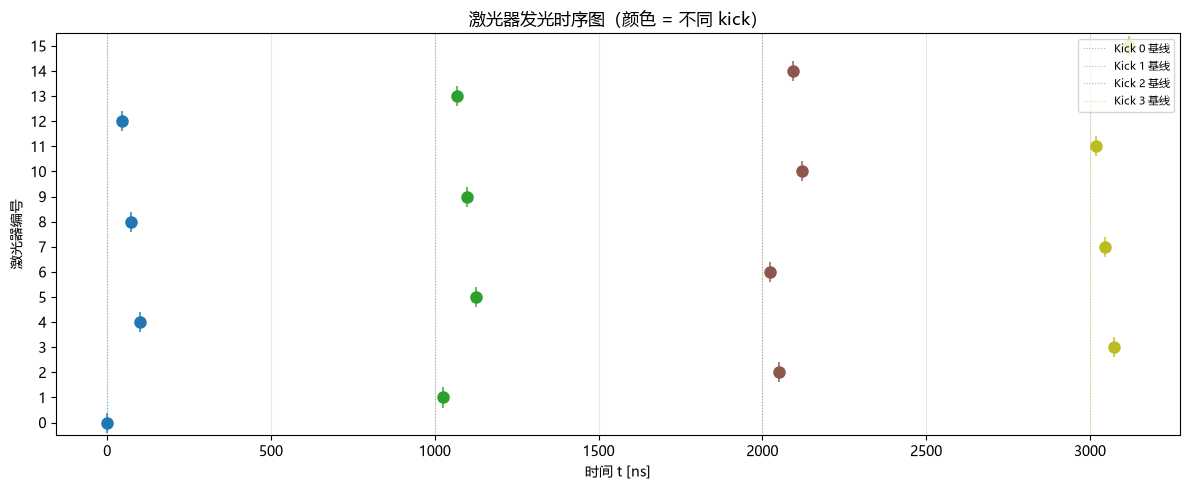

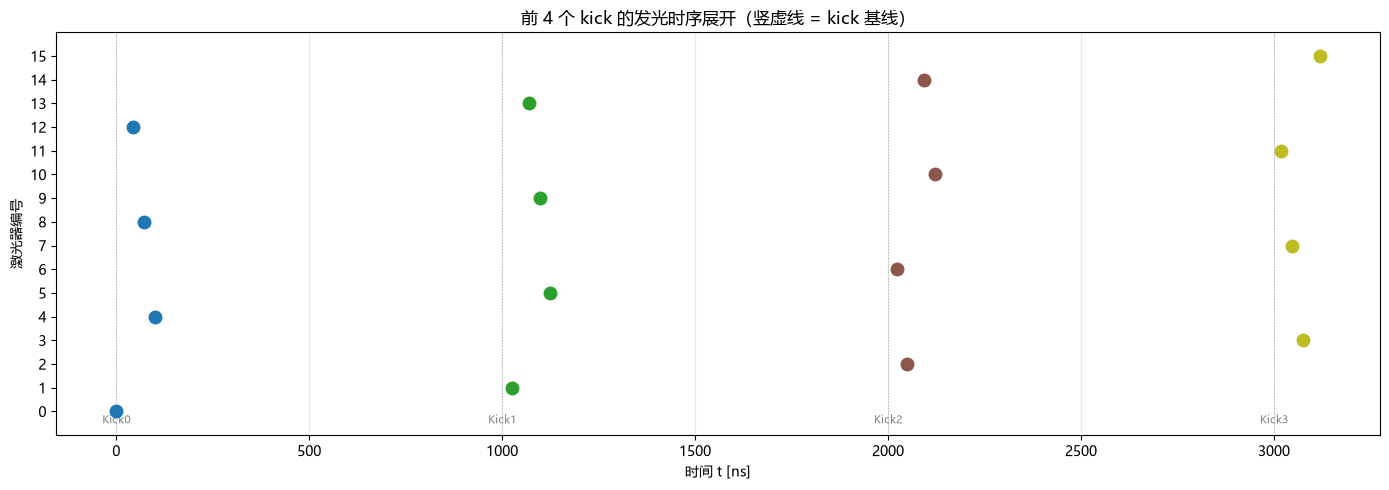

In [8]:
# ============================================================================
# 绘图 1：激光器发光时序图
# ============================================================================
# 画出每个激光器在时间轴上的发光时刻，用颜色区分不同 kick

fig, ax = plt.subplots(figsize=(12, 5))

# 为每个 kick 分配颜色
colors_kick = plt.cm.tab10(np.linspace(0, 0.85, N_KICKS))

for k_idx, lasers in enumerate(TIMING_DIAGRAM):
    col = colors_kick[k_idx]
    for lid in lasers:
        off = laser_fire_offset(lid)
        t_ns = k_idx * KICK_SPACING / NS + off / NS
        ax.plot(t_ns, lid, "o", color=col, ms=8, zorder=5)
        ax.vlines(t_ns, lid - 0.4, lid + 0.4, color=col, lw=1.5, alpha=0.7)
    # 标注 kick 基线
    base_ns = k_idx * KICK_SPACING / NS
    ax.axvline(base_ns, color=col, ls=":", lw=0.8, alpha=0.5,
               label=f"Kick {k_idx} 基线" if k_idx < 5 else "")

ax.set_xlabel("时间 t [ns]")
ax.set_ylabel("激光器编号")
ax.set_yticks(range(N_LASERS))
ax.set_ylim(-0.5, N_LASERS - 0.5)
ax.set_title("激光器发光时序图（颜色 = 不同 kick）")
ax.legend(fontsize=8, loc="upper right")
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig("crosstalk_v01_firing_timing.png", dpi=110, bbox_inches="tight")
plt.show()

# 展开时间轴版本：只看前几个 kick 的细节
fig, ax = plt.subplots(figsize=(14, 5))
for k_idx in range(min(4, N_KICKS)):
    lasers = TIMING_DIAGRAM[k_idx]
    col = colors_kick[k_idx]
    for lid in lasers:
        off = laser_fire_offset(lid)
        t_ns = k_idx * KICK_SPACING / NS + off / NS
        ax.plot(t_ns, lid, "o", color=col, ms=9, zorder=5)
    base_ns = k_idx * KICK_SPACING / NS
    ax.axvline(base_ns, color="gray", ls=":", lw=0.8, alpha=0.5)
    # 标注"该 kick 基线"文字
    ax.text(base_ns, -0.5, f"Kick{k_idx}", fontsize=8, ha="center", color="gray")

ax.set_xlabel("时间 t [ns]")
ax.set_ylabel("激光器编号")
ax.set_yticks(range(N_LASERS))
ax.set_ylim(-1, N_LASERS)
ax.set_title("前 4 个 kick 的发光时序展开（竖虚线 = kick 基线）")
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig("crosstalk_v01_firing_detail.png", dpi=110, bbox_inches="tight")
plt.show()


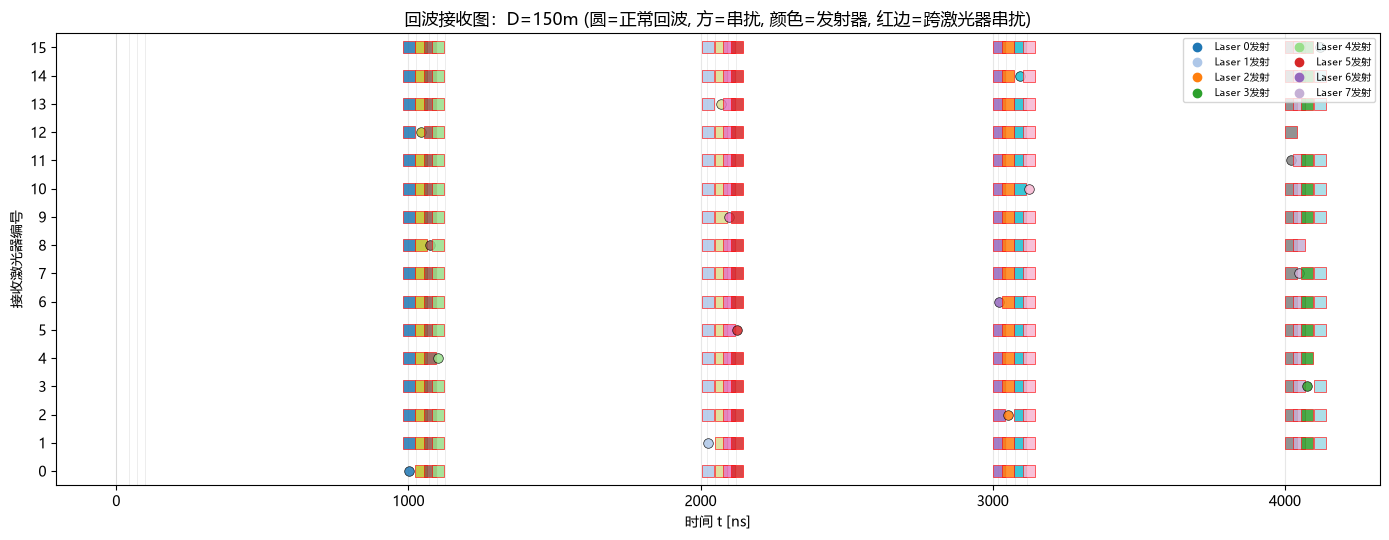

回波图: D=150m, 共 246 条记录
  发射激光器: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  接收激光器: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]


In [9]:
# ============================================================================
# 绘图 2：回波接收图（颜色区分布发射器）
# ============================================================================
# 选一个特定距离 D，画出所有回波被各激光器接收的情况

D_SHOW = 150.0                        # 示例距离（可调）
res_show = results_by_distance.get(D_SHOW, [])
if not res_show:
    res_show = detect_echoes_for_target(D_SHOW)

fig, ax = plt.subplots(figsize=(14, 5.5))

# 每个发射器用不同颜色
emit_colors = plt.cm.tab20(np.linspace(0, 1, N_LASERS))

# 画每个激光器的发光时刻（作为基线标记）
for lid in range(N_LASERS):
    # 找到该激光器每次发光时刻
    for _k, _l, _tf, _tn in firing_events:
        if _l == lid:
            ax.axvline(_tn, color="0.75", lw=0.5, alpha=0.4, zorder=1)

# 画回波接收事件
for emit_lid, det_lid, t_echo, calc_d in res_show:
    if det_lid == emit_lid:
        # 正常回波（发射器自己收到）
        marker = "o"
        size = 6
        edge = "k"
    else:
        # 串扰（别人收到）
        marker = "s"
        size = 8
        edge = "red"
    ax.scatter(t_echo * 1e9, det_lid, marker=marker, s=size*8,
               color=emit_colors[emit_lid], edgecolors=edge, linewidths=0.5,
               zorder=5, alpha=0.85)

# 标注
ax.set_xlabel("时间 t [ns]")
ax.set_ylabel("接收激光器编号")
ax.set_yticks(range(N_LASERS))
ax.set_ylim(-0.5, N_LASERS - 0.5)
ax.set_title(f"回波接收图：D={D_SHOW:.0f}m "
             f"(圆=正常回波, 方=串扰, 颜色=发射器, 红边=跨激光器串扰)")
ax.grid(alpha=0.3, axis="x")
# 图例：发射器颜色
for lid in range(min(8, N_LASERS)):
    ax.plot([], [], "o", color=emit_colors[lid], label=f"Laser {lid}发射")
ax.legend(fontsize=7, ncol=2, loc="upper right")
plt.tight_layout()
plt.savefig("crosstalk_v01_echo_map.png", dpi=110, bbox_inches="tight")
plt.show()

print(f"回波图: D={D_SHOW:.0f}m, 共 {len(res_show)} 条记录")
emit_set = set(r[0] for r in res_show)
det_set  = set(r[1] for r in res_show)
print(f"  发射激光器: {sorted(emit_set)}")
print(f"  接收激光器: {sorted(det_set)}")


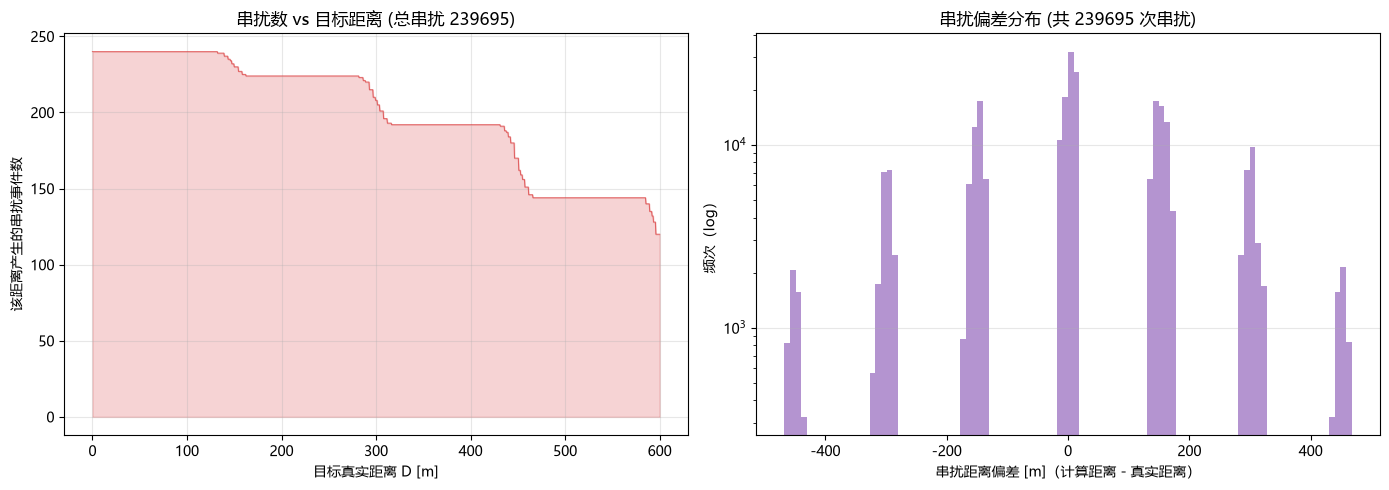

串扰分析汇总
  总目标数: 1201
  总回波记录: 258911
  总串扰事件: 239695
  串扰距离偏差:
    均值: 17.18 m
    标准差: 184.47 m
    范围: [-467.5, 467.5] m
    偏差=0 的数: 7527

  最容易受串扰的激光器(前5):
    Laser 15: 18015 次
    Laser 3: 18001 次
    Laser 7: 17984 次
    Laser 11: 17959 次
    Laser 10: 16883 次

  最容易产生串扰的激光器(前5):
    Laser 0: 18015 次
    Laser 12: 18001 次
    Laser 8: 17984 次
    Laser 4: 17959 次
    Laser 1: 16848 次


In [10]:
# ============================================================================
# 绘图 3：串扰分析 —— 每个距离的串扰数 & 串扰距离分布
# ============================================================================

# 每个距离的串扰数
D_vals = np.array(sorted(ghost_by_dist.keys()))
ghost_vals = np.array([ghost_by_dist[d] for d in D_vals])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：串扰数 vs 目标距离
ax = axes[0]
ax.plot(D_vals, ghost_vals, "-", color="tab:red", lw=0.8, alpha=0.6)
ax.fill_between(D_vals, ghost_vals, alpha=0.2, color="tab:red")
ax.set_xlabel("目标真实距离 D [m]")
ax.set_ylabel("该距离产生的串扰事件数")
ax.set_title(f"串扰数 vs 目标距离 (总串扰 {ghost_count})")
ax.grid(alpha=0.3)

# 右图：串扰距离偏差 —— 被哪个激光器算成了多少距离
# 收集所有串扰事件中"计算距离 - 真实距离"的偏差
ghost_errors = []
for D, res in results_by_distance.items():
    for emit_lid, det_lid, t_echo, calc_d in res:
        if det_lid != emit_lid:
            ghost_errors.append((D, calc_d - D, det_lid, emit_lid))

if ghost_errors:
    err_arr = np.array([ge[1] for ge in ghost_errors])
    ax = axes[1]
    ax.hist(err_arr, bins=100, color="tab:purple", alpha=0.7, log=True)
    ax.set_xlabel("串扰距离偏差 [m]（计算距离 - 真实距离）")
    ax.set_ylabel("频次（log）")
    ax.set_title(f"串扰偏差分布 (共 {len(ghost_errors)} 次串扰)")
    ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("crosstalk_v01_ghost_analysis.png", dpi=110, bbox_inches="tight")
plt.show()

print("=" * 76)
print("串扰分析汇总")
print("=" * 76)
print(f"  总目标数: {len(D_targets)}")
print(f"  总回波记录: {sum(len(v) for v in results_by_distance.values())}")
print(f"  总串扰事件: {ghost_count}")
if ghost_errors:
    err_arr = np.array([ge[1] for ge in ghost_errors])
    print(f"  串扰距离偏差:")
    print(f"    均值: {np.mean(err_arr):.2f} m")
    print(f"    标准差: {np.std(err_arr):.2f} m")
    print(f"    范围: [{np.min(err_arr):.1f}, {np.max(err_arr):.1f}] m")
    print(f"    偏差=0 的数: {np.sum(np.abs(err_arr) < 1e-6)}")
    # 哪些激光器最容易产生串扰
    from collections import Counter
    top_det = Counter(ge[2] for ge in ghost_errors).most_common(5)
    print(f"\n  最容易受串扰的激光器(前5):")
    for lid, cnt in top_det:
        print(f"    Laser {lid}: {cnt} 次")
    top_emit = Counter(ge[3] for ge in ghost_errors).most_common(5)
    print(f"\n  最容易产生串扰的激光器(前5):")
    for lid, cnt in top_emit:
        print(f"    Laser {lid}: {cnt} 次")


In [11]:
# ============================================================================
# 总结
# ============================================================================
print("=" * 76)
print("crosstalk_sim_v01 总结")
print("=" * 76)
print()
print("1. 系统配置")
print(f"   - 短焦模组: {N_LASERS} 个激光器")
print(f"   - 有效射程: 0 ~ {D_MAX:.0f} m")
print(f"   - 最大可探测距离: 0 ~ {D_DETECT_MAX:.0f} m (N={D_RANGE_N})")
print(f"   - 目标扫描: {D_TARGET_MIN:.0f} ~ {D_TARGET_MAX:.0f} m, 步长 {D_TARGET_STEP:.1f} m")
print(f"   - Kick 间隔: {KICK_SPACING*1e9:.0f} ns")
print(f"   - 时序图: {N_KICKS} 个 kick")
print()
print("2. 编码方案")
print(f"   - tx_trig_dly: 1ns 步长（各激光器不同）")
print(f"   - FPGA 抖动: 8ns 步长（各激光器不同）")
print(f"   - delta_dly: 暂未使用")
print()
print("3. 串扰检测")
print(f"   - 总目标数: {len(D_targets)}")
print(f"   - 总回波记录: {sum(len(v) for v in results_by_distance.values())}")
print(f"   - 总串扰事件: {ghost_count}")
print(f"   - 串扰率: {ghost_count/max(sum(len(v) for v in results_by_distance.values()),1)*100:.1f}%")
print()
print("4. 使用说明")
print("   - 修改 TIMING_DIAGRAM，自定义激光器发光顺序")
print("   - 修改 LASER_ENCODING，调整每个激光器的编码参数")
print("   - 修改 D_TARGET_STEP，控制目标扫描密度")
print("   - 修改 D_RANGE_N，控制可探测距离倍数")


crosstalk_sim_v01 总结

1. 系统配置
   - 短焦模组: 16 个激光器
   - 有效射程: 0 ~ 300 m
   - 最大可探测距离: 0 ~ 600 m (N=2)
   - 目标扫描: 0 ~ 600 m, 步长 0.5 m
   - Kick 间隔: 1000 ns
   - 时序图: 4 个 kick

2. 编码方案
   - tx_trig_dly: 1ns 步长（各激光器不同）
   - FPGA 抖动: 8ns 步长（各激光器不同）
   - delta_dly: 暂未使用

3. 串扰检测
   - 总目标数: 1201
   - 总回波记录: 258911
   - 总串扰事件: 239695
   - 串扰率: 92.6%

4. 使用说明
   - 修改 TIMING_DIAGRAM，自定义激光器发光顺序
   - 修改 LASER_ENCODING，调整每个激光器的编码参数
   - 修改 D_TARGET_STEP，控制目标扫描密度
   - 修改 D_RANGE_N，控制可探测距离倍数
